# Analise de Criminalidade no Rio de Janeiro

In [68]:
# importar bibliotecas
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

ENDERECO_DADOS = 'https://www.ispdados.rj.gov.br/Arquivos/BaseDPEvolucaoMensalCisp.csv'

# Obtendo os dados 
try:
    df_roubos = pd.read_csv(ENDERECO_DADOS, encoding="iso-8859-1", sep=';')
    print(df_roubos['regiao'].unique())
    print(df_roubos.head())
except Exception as e:
    print("Erro ao obter dados do ISP:", e)


['Capital' 'Baixada Fluminense' 'Interior'
 'Grande NiterÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â³i' 'Grande Niterói']
   cisp  mes   ano  mes_ano  aisp  risp           munic    mcirc   regiao  \
0     1    1  2003  2003m01     5     1  Rio de Janeiro  3304557  Capital   
1     4    1  2003  2003m01     5     1  Rio de Janeiro  3304557  Capital   
2     5    1  2003  2003m01     5     1  Rio de Janeiro  3304557  Capital   
3     6    1  2003  2003m01     1     1  Rio de Janeiro  3304557  Capital   
4     7    1  2003  2003m01     1     1  Rio de Janeiro  3304557  Capital   

   hom_doloso  ...  cmp  cmba  ameaca  pessoas_desaparecidas  \
0           0  ...  NaN   NaN      21                      2   
1           3  ...  NaN   NaN      15                      6   
2           3  ...  NaN   NaN      47                      2   
3           6  ...  NaN   NaN      26                      2   
4           4  ...  NaN   NaN      10                      1   

   encontro_cadaver  encontro_ossada 

In [69]:
# Tratando E preparando os dados 
try:
    # Delimitando as variáveis 
    df_roubos = df_roubos[['cisp', 'regiao', 'munic', 'roubo_veiculo']]
    # print(df_roubos.head())

    # Procura na coluna 'regiao' todos os valores que começam com 'Grande Niter'
    # Isso ajuda a identificar textos digitados de forma incompleta ou sem acentuação
    # Exemplo: 'Grande Niteroi', 'Grande Niter', etc.
    # O parâmetro na=False evita erro caso existam valores vazios (NaN)
    correcao_acentuacao = df_roubos['regiao'].str.startswith('Grande Niter', na=False)

    # Filtro para corrigir DADOS
    df_roubos.loc[correcao_acentuacao, 'regiao'] = 'Grande Niterói'
    print(df_roubos['regiao'].unique()) #Imprimir apenas valores únicos da coluna 'regiao' para verificar a correção

    # Agrupando os dados por cisp, região
    df_roubos = df_roubos.groupby(['cisp', 'regiao', 'munic'], as_index=False)['roubo_veiculo'].sum()
    
    # Exibindo DataFrame tratado
    display(df_roubos)

except Exception as e:
    print("Erro no tratamento dos dados:", e)


['Capital' 'Baixada Fluminense' 'Interior' 'Grande Niterói']


,cisp,regiao,munic,roubo_veiculo
0,1,Capital,Rio de Janeiro,579
1,4,Capital,Rio de Janeiro,2205
2,5,Capital,Rio de Janeiro,1366
3,6,Capital,Rio de Janeiro,4640
4,7,Capital,Rio de Janeiro,2018
...,...,...,...,...
141,159,Interior,Cachoeiras de Macacu,286
142,165,Interior,Mangaratiba,500
143,166,Interior,Angra dos Reis,971
144,167,Interior,Paraty,106


In [70]:
# Agrupando população 
try:
    df_roubos = df_roubos.groupby(['regiao', 'munic'], as_index=False)['roubo_veiculo'].sum() 

    # ============================

    # IBGE
    df_populacao = pd.read_excel(
        'POP2025_20260113.xls',
         sheet_name='Municípios',
         skiprows=1) # Ajuste o nome do arquivo conforme necessário
  
    # df_populacao = pd.read_excel('ibge.xlsx')
    # print(df_populacao.head())
    print(df_populacao.columns)

    df_populacao = df_populacao.rename(columns={
        'NOME DO MUNICÍPIO':'munic',
        'POPULAÇÃO ESTIMADA':'populacao',
        'UF':'uf'
    })

    # Removendo ponto de milhar e convertendo para numero

    df_populacao['populacao'] = pd.to_numeric(df_populacao['populacao'], errors='coerce') # Converte para numérico, definindo erros como NaN

    df_populacao['munic'] = df_populacao['munic'].str.strip()  # Remove espaços em branco extras

    df_populacao = df_populacao[['munic', 'populacao']] # Seleciona apenas as colunas necessárias
    df_populacao = df_populacao.sort_values('populacao', ascending=False).drop_duplicates(subset=['munic']) # Remove duplicatas com base na coluna 'munic'
    # Mergindo os dados de roubos com os dados de população
    df_roubos = pd.merge(
        df_roubos,
        df_populacao,
        on='munic',
        how='left'
    )
    
    # print(df_roubos.head())
    print(df_roubos.columns)

except Exception as e:
    print("Erro ao obter dados de população:", e)

# print(df_populacao[df_populacao['munic'] == 'Mesquita'])
    


Index(['UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'POPULAÇÃO ESTIMADA', 'Unnamed: 5'],
      dtype='object')
Index(['regiao', 'munic', 'roubo_veiculo', 'populacao'], dtype='object')


In [71]:
# Calculando as medidas 
try:
    array_roubos = np.array(df_roubos['roubo_veiculo'])
    # print(array_roubos)

    media = np.mean(array_roubos)
    mediana = np.median(array_roubos)
    total = np.sum(array_roubos)
    maximo = np.max(array_roubos)

    # obtendo os quartis
    q1 = np.quantile(array_roubos, 0.25)
    q3 = np.quantile(array_roubos, 0.75)

    # Priontando as medidas
    print('Medidas:')
    print(f'Média: {media:.2f}')
    print(f'Mediana: {mediana}')
    print(f'Total: {total}')

except Exception as e:
    print("Erro ao obter as medidas:", e)

Medidas:
Média: 7988.27
Mediana: 256.0
Total: 718944


In [72]:
# Identificando os maiores e menores 
try:
    print('Criando os dataframes dos maiores e menores...')
    
    df_maiores = df_roubos[df_roubos['roubo_veiculo'] >= q3].copy()

    # Nova coluna chamada 'flag' para marcar registros como "mais"
    df_maiores['flag'] = 'mais'

    # DataFrame dos menores
    df_menores = df_roubos[df_roubos['roubo_veiculo'] <= q1].copy()

    # Nova coluna chamada 'flag' para marcar registros como "menos"
    df_menores['flag'] = 'menos'

    # Concatenando os dataframes dos maiores e menores
    df_roubos_flags = pd.concat([df_maiores, df_menores], ignore_index=True)

    display(df_roubos_flags)

except Exception as e:
    print("Erro ao identificar os maiores e menores:", e)

Criando os dataframes dos maiores e menores...


,regiao,munic,roubo_veiculo,populacao,flag
0,Baixada Fluminense,Belford Roxo,24731,518384.0,mais
1,Baixada Fluminense,Duque de Caxias,69024,866225.0,mais
2,Baixada Fluminense,Itaguaí,4042,124021.0,mais
3,Baixada Fluminense,Japeri,1175,102171.0,mais
4,Baixada Fluminense,Magé,3650,244142.0,mais
5,Baixada Fluminense,Mesquita,8493,178830.0,mais
6,Baixada Fluminense,Nilópolis,12481,155500.0,mais
7,Baixada Fluminense,Nova Iguaçu,43631,843220.0,mais
8,Baixada Fluminense,Queimados,2416,149135.0,mais
9,Baixada Fluminense,Seropédica,1951,84794.0,mais


In [73]:
# Exportando dados csv ou xlsx
try:
    print('Exportando os dataframes...')
    ## Testar sem encoding | Impirmir com o encoding utf-8-sig, se precisar do csv fora do BI
    df_roubos_flags.to_csv('roubos_veiculos.csv', index=False)

    df_roubos_flags.to_excel('roubos_veiculos.xlsx', index=False)

    print('Dados exportados com sucesso!')
    
except Exception as e:
    print("Erro ao exportar os dados:", e)

Exportando os dataframes...
Dados exportados com sucesso!


In [74]:
# Calculando por 1000 habitantes
try:
    df_roubos['roubo_por_1000ab'] = (
        df_roubos['roubo_veiculo'] / df_roubos['populacao']
    ) * 1000
    # print(df_roubos[['munic', 'roubo_por_1000ab']].head())
    print(df_roubos[['munic', 'roubo_veiculo', 'populacao', 'roubo_por_1000ab']].head(20))

except Exception as e:
    print("Erro ao calcular por 1000 habitantes:", e)

                 munic  roubo_veiculo  populacao  roubo_por_1000ab
0         Belford Roxo          24731   518384.0         47.707877
1      Duque de Caxias          69024   866225.0         79.683685
2           Guapimirim            772    54311.0         14.214432
3              Itaguaí           4042   124021.0         32.591255
4               Japeri           1175   102171.0         11.500328
5                 Magé           3650   244142.0         14.950316
6      Magé;Guapimirim            592        NaN               NaN
7             Mesquita           8493   178830.0         47.492032
8            Nilópolis          12481   155500.0         80.263666
9          Nova Iguaçu          43631   843220.0         51.743317
10           Paracambi            345    43627.0          7.907947
11           Queimados           2416   149135.0         16.200087
12    Queimados;Japeri            109        NaN               NaN
13          Seropédica           1951    84794.0         23.00

In [75]:
# Insght top 10 municípios com mais roubos por 1000 habitantes
try:
    top10 = df_roubos.sort_values(by='roubo_por_1000ab', ascending=False).head(10)
    print(top10[['munic', 'roubo_por_1000ab']])

except Exception as e:
    print('Erro ao obter os insightts', e)
    """LEMBRAR DE NUMERAR CERTINHO AO LADO"""

                 munic  roubo_por_1000ab
8            Nilópolis         80.263666
1      Duque de Caxias         79.683685
14  São João de Meriti         69.847354
15      Rio de Janeiro         59.240834
18         São Gonçalo         58.678645
9          Nova Iguaçu         51.743317
0         Belford Roxo         47.707877
7             Mesquita         47.492032
17             Niterói         43.062229
3              Itaguaí         32.591255


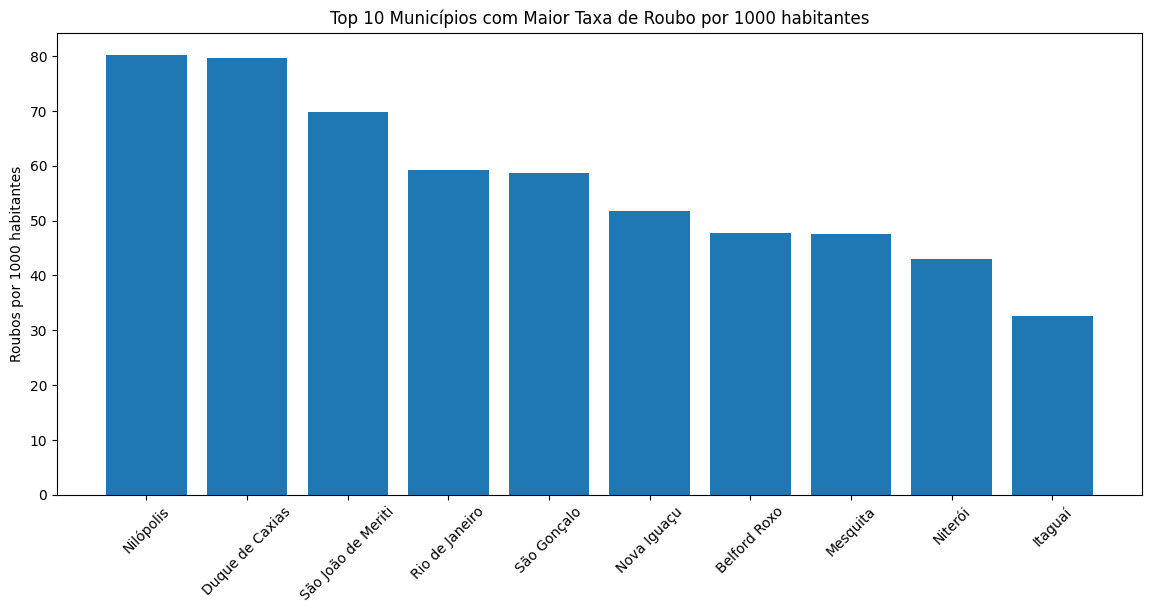

<Figure size 640x480 with 0 Axes>

In [76]:
plt.figure(figsize=(14, 6))

plt.bar(
    top10['munic'],
    top10['roubo_por_1000ab']
)

plt.xticks(rotation=45)

plt.title("Top 10 Municípios com Maior Taxa de Roubo por 1000 habitantes")

# plt.xlabel('Municípios')
plt.ylabel('Roubos por 1000 habitantes')
plt.show()
plt.tight_layout()
